# <span style="color:green"> Lecture 03 notebook </span>

In [8]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

## <span style="color:blue">  Exercise 03.1 </span>

Per svolgere l'esercitazione sono stati calcolati $M= 100000$ prezzi iniziali di call e put option, divisi in $N=100$ blocchi. Per calcolare $P[S(0), 0]$ e $C[S(0), 0]$ sono stati utilizzat due metodi:

1. Campionando direttamente $S(t)$ con la formula chiusa $$S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right],$$ con $W(t)\sim\mathcal{N}(0,t)$;
2. Utilizzando una formula ricorsiva $$S(t_{i+1}) = S(t_i) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i)
    +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right],$$ con $Z_i \sim \mathcal{N}(0,1)$.

Dopo aver calcolato il valore del sottostante al tempo $T$, il prezzo iniziale dell'opzione deve essere scontato del guadagno rappresentato da un investimento dal ritorno "certo", a risk-free rate $r$. Dato lo strike price $K$, si definisce il profitto per una call come $$(S(T) - K)^+ := \max[0, S(T) - K].$$

Il prezzo iniziale per una call, scontato del risk free rate, darà dato da 
$$C[S(0), 0] = \langle e^{-rT}(S(T)-K)^+\rangle.$$

Allo, stesso modo, il prezzo iniziale per una put option sarà dato da 
$$P[S(0), 0] = \langle e^{-rT}(K-S(T))^+\rangle.$$

## <span style="color:black">  Calcolo del prezzo con valore finale </span>

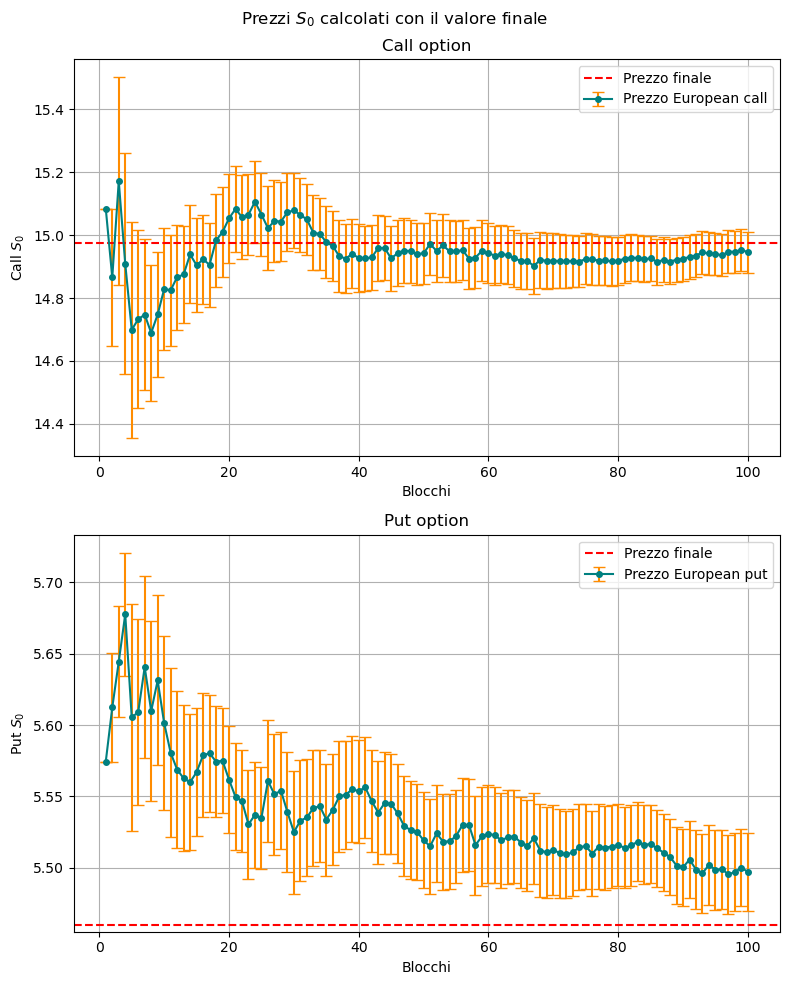

In [75]:
M=100000
N=100
L=int(M/N)

fig, axes = plt.subplots(2, 1, figsize=(8, 10))
r = np.arange(N)

x, y = np.loadtxt('call_data.txt', unpack = True)

axes[0].errorbar(r+1,x,yerr=y, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Prezzo European call')
axes[0].set_title('Call option')
axes[0].axhline(y = 14.975790778311286, color = 'r', linestyle = '--', label = 'Prezzo finale')
axes[0].set_xlabel('Blocchi')
axes[0].set_ylabel('C[S(0), 0]')
axes[0].legend()
axes[0].grid(True)

x_p, y_p =np.loadtxt('put_data.txt', unpack = True)
axes[1].errorbar(r+1,x_p,yerr=y_p, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Prezzo European put')
axes[1].set_title('Put option')
axes[1].axhline(y = 5.4595325819072364, color = 'r', linestyle = '--', label = 'Prezzo finale')
axes[1].set_xlabel('Blocchi')
axes[1].set_ylabel('P[S(0), 0]')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Prezzi $S_0$ calcolati con il valore finale')
plt.tight_layout()
plt.show()



  

## <span style="color:black">  Calcolo del prezzo con valori intermedi </span>

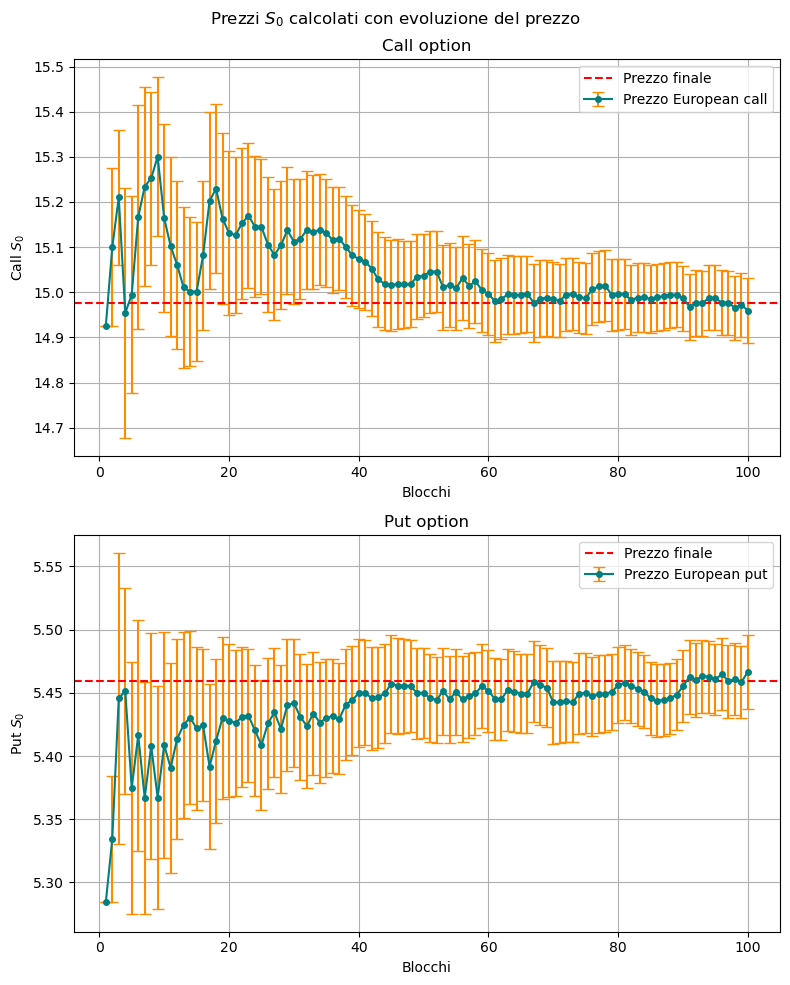

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
r = np.arange(N)

x, y = np.loadtxt('path_call_data.txt', unpack = True)

axes[0].errorbar(r+1,x,yerr=y, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Prezzo European call')
axes[0].set_title('Call option')
axes[0].axhline(y = 14.975790778311286, color = 'r', linestyle = '--', label = 'Prezzo finale')
axes[0].set_xlabel('Blocchi')
axes[0].set_ylabel('C[S(0), 0]')
axes[0].legend()
axes[0].grid(True)

x_p, y_p =np.loadtxt('path_put_data.txt', unpack = True)
axes[1].errorbar(r+1,x_p,yerr=y_p, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Prezzo European put')
axes[1].set_title('Put option')
axes[1].axhline(y = 5.4595325819072364, color = 'r', linestyle = '--', label = 'Prezzo finale')
axes[1].set_xlabel('Blocchi')
axes[1].set_ylabel('P[S(0), 0]')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Prezzi $S_0$ calcolati con evoluzione del prezzo')
plt.tight_layout()
plt.show()



  


Possiamo osservare come tutti i prezzi $C[S(0), 0]$ e $P[S(0), 0]$ convergano, al massimo entro $2\sigma$, al valore atteso calcolato con la soluzione analitica di Black e Scholes. Questo si verifica indipendentemente dal metodo di calcolo del prezzo iniziale, sia questo utilizzando la formula chiusa per il valore finale dell'asset o ricostruendo il valore a seguito di evoluzione lungo tutto l'intervallo di tempo.

Il primo metodo consiste nel campionare direttamente $S(T)$. Poiché gli incrementi $W(t)$ di moto browniano standard sono indipendenti e normalmente distribuiti, possiamo calcolare i valori di un asset $S$ che segue moto browniano geometrico $GBM(\mu, \sigma^2)$ con una formula chiusa che permette di valutare il valore in un unico time step $T$, restituendo l'esatta distribuzione dei prezzi all'istante finale e rendendo i due metodi equivalenti.

Il prezzo delle put options è molto più basso di quello delle call options poiché il drift positivo $\mu$ spinge il valor medio della distribuzione sopra il valore $K$, rendendo più probabile la realizzazione di un guadagno per una call.



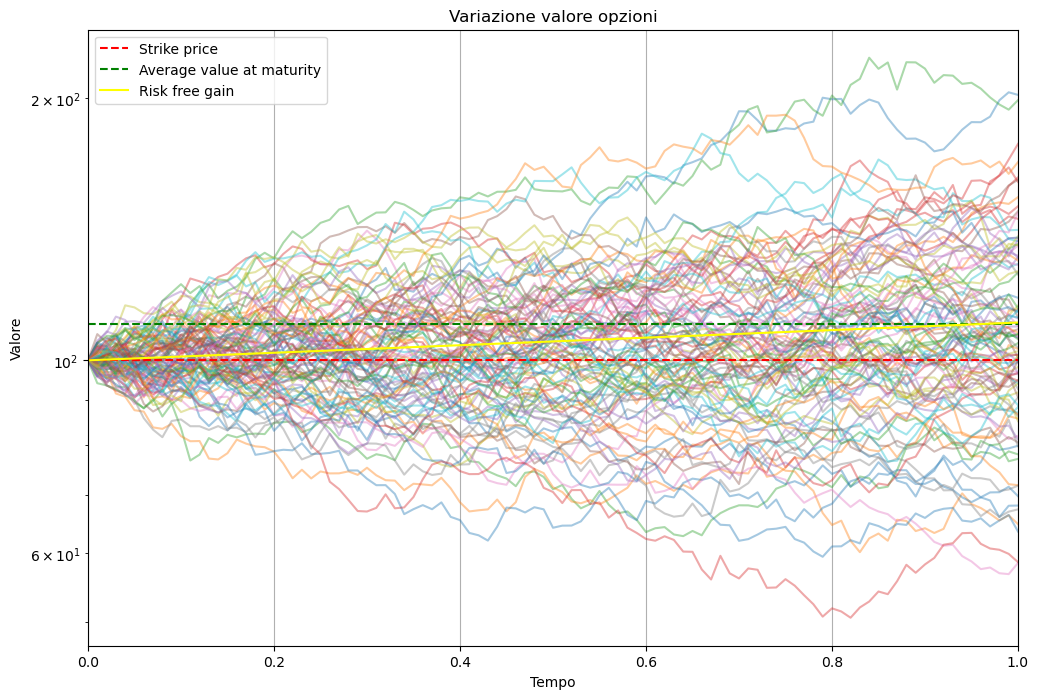

Probabilità di guadagno call: 0.61


In [85]:
K=100

plt.figure(figsize=(12, 8))
time = np.loadtxt("paths.txt", usecols = 0, unpack = True)
sum_data = 0
in_the_money = 0

for i in range(100):
    data = np.loadtxt("paths.txt", usecols = i+1, unpack = True)
    sum_data += data[-1]
    if (data[-1] > K):
        in_the_money +=1
    
    plt.plot(time, data, alpha = 0.4)
    plt.title('Variazione valore opzioni')

plt.axhline(y = K, color = 'r', linestyle = '--', label = 'Strike price')
plt.axhline(y = sum_data/100, color = 'g', linestyle = '--', label = 'Average value at maturity')
plt.plot(time, K*np.exp(0.1*time), color = 'yellow', label = 'Risk free gain')
plt.xlabel('Tempo')
plt.ylabel('Valore')
plt.yscale('log')
plt.xlim([0,1])
plt.legend()
plt.grid(True)
plt.show()

print(f"Probabilità di guadagno call:", in_the_money/100)


Volevo solo vedere la dispersione nel tempo del valore di 100 opzioni. Ho messo l'asse delle ordinate in scala logaritmica per osservare meglio l'andamento geometrico del prezzo (e per togliere l'illusione che si guadagni più di quanto si perda). 

- In verde il valore medio al tempo di maturazione T.
- In rosso lo strike price K.
- In giallo l'evoluzione esponenziale di $S_0$ investito a risk free rate.

Il grafico rende anche evidente come nessuno comprerebbe un'opzione di questo tipo, con $\mu = r$, dal momento che il ritorno atteso è uguale al risk free rate, ma la volatilità è molto maggiore.